# Feature Engineering Candidates

Candidate features grouped by experience, quality, punctuality, cost, and availability.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [2]:
enriched = load_enriched_tasks()

feature_rows = []
for group_name, columns in FEATURE_GROUPS.items():
    for column in columns:
        series = pd.to_numeric(enriched[column], errors="coerce") if column in enriched.columns else pd.Series(dtype=float)
        feature_rows.append(
            {
                "feature_group": group_name,
                "feature": column,
                "missing_pct": round(enriched[column].isna().mean() * 100, 2) if column in enriched.columns else 100.0,
                "n_unique": enriched[column].nunique(dropna=True) if column in enriched.columns else 0,
                "median": series.median() if column in enriched.columns else np.nan,
                "p95": series.quantile(0.95) if column in enriched.columns else np.nan,
            }
        )
feature_catalog = pd.DataFrame(feature_rows)
display(feature_catalog)

,feature_group,feature,missing_pct,n_unique,median,p95
0,experience,PRIOR_HOURS_TRANSLATOR,0.00,733786,5092.160000,18210.878000
1,experience,PRIOR_HOURS_CLIENT,0.00,467921,770.730000,11452.980000
2,experience,PRIOR_HOURS_SECTOR,0.00,594089,2088.660000,12947.640000
3,experience,PRIOR_HOURS_TASK_TYPE,0.00,591294,2167.980000,11279.698000
4,experience,PRIOR_TASKS_LANGUAGE_PAIR,0.00,44085,2032.000000,23264.400000
5,quality,PRIOR_QUALITY_MEAN_TRANSLATOR,0.10,751796,6.966152,7.500000
6,quality,ROLLING_QUALITY_MEAN_5,0.10,70,7.000000,8.200000
7,quality,ROLLING_QUALITY_STD_5,0.18,15309,1.303840,2.167948
8,quality,PRIOR_QUALITY_MEAN_PAIR,0.47,631919,6.967732,7.547043
9,quality,PRIOR_QUALITY_MEAN_TASK_TYPE,0.29,574802,6.956415,7.555556


## Experience features

,count,mean,std,min,25%,50%,75%,max
PRIOR_HOURS_TRANSLATOR,997933.0,6892.510663,6160.634501,0.0,2199.83,5092.16,10219.86,38255.45
PRIOR_HOURS_CLIENT,997933.0,2642.211966,3827.594747,0.0,95.06,770.73,3386.54,18969.25
PRIOR_HOURS_SECTOR,997933.0,3887.616422,4325.612866,0.0,623.86,2088.66,5956.80,24070.35
PRIOR_HOURS_TASK_TYPE,997933.0,3524.738100,3762.720268,0.0,670.39,2167.98,5375.08,30105.28
PRIOR_TASKS_LANGUAGE_PAIR,997933.0,4996.969142,7737.928149,0.0,517.00,2032.00,5757.00,44084.00


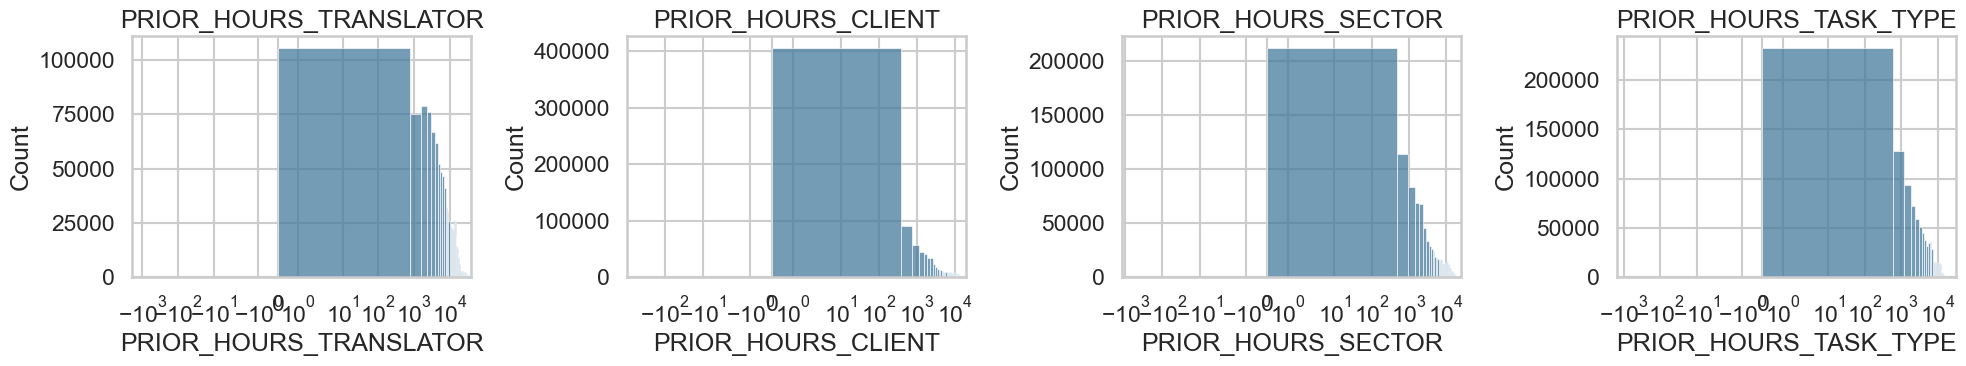

## Quality features

,count,mean,std,min,25%,50%,75%,max
PRIOR_QUALITY_MEAN_TRANSLATOR,996950.0,7.025873,0.281431,2.0,6.938759,6.966152,7.052346,10.000000
ROLLING_QUALITY_MEAN_5,996950.0,7.042868,0.728573,2.0,6.600000,7.000000,7.400000,10.000000
ROLLING_QUALITY_STD_5,996115.0,1.329065,0.498568,0.0,1.000000,1.303840,1.643168,4.438468
PRIOR_QUALITY_MEAN_PAIR,993245.0,7.026261,0.314443,2.0,6.933786,6.967732,7.061198,10.000000
PRIOR_QUALITY_MEAN_TASK_TYPE,995055.0,7.017424,0.321342,1.0,6.926741,6.956415,7.021237,10.000000
PRIOR_QUALITY_COUNT_TRANSLATOR,997933.0,8061.357967,11409.367142,0.0,1158.000000,3722.000000,9414.000000,65208.000000


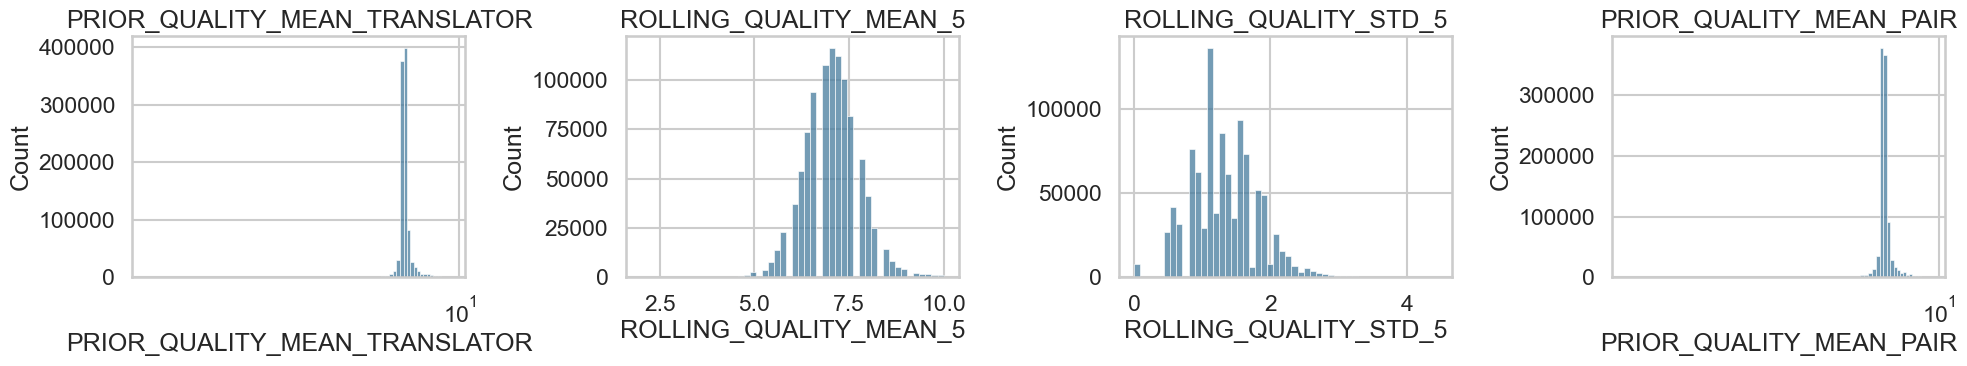

## Punctuality features

,count,mean,std,min,25%,50%,75%,max
PRIOR_ON_TIME_RATE_TRANSLATOR,996950.0,0.759475,0.146212,0.0,0.652439,0.775682,0.879630,1.0
PRIOR_ON_TIME_RATE_TASK_TYPE,995055.0,0.755862,0.157382,0.0,0.645457,0.761905,0.890057,1.0
PRIOR_AVG_LATENESS_MINUTES,996950.0,433.776684,9045.248303,0.0,41.904998,121.049214,246.657967,1861411.5
ROLLING_ON_TIME_RATE_5,996950.0,0.758150,0.269459,0.0,0.600000,0.800000,1.000000,1.0
PUNCTUALITY_TREND_DELTA,994002.0,0.000227,0.240447,-0.8,-0.200000,0.000000,0.200000,0.8


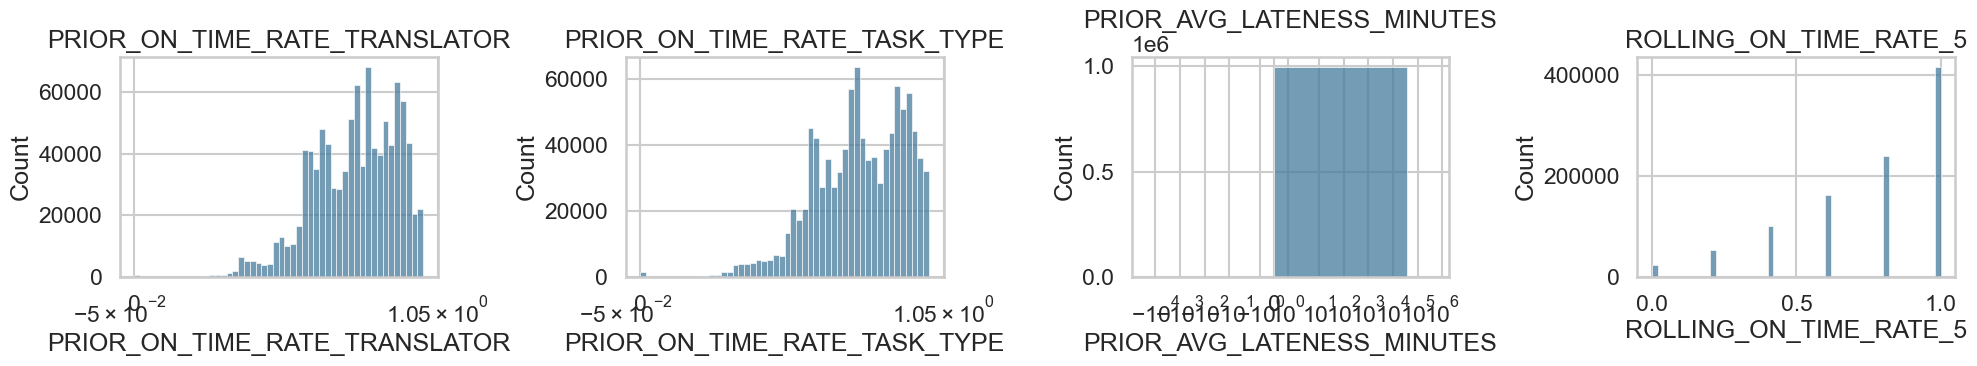

## Cost features

,count,mean,std,min,25%,50%,75%,max
PAIR_HOURLY_RATE,997926.0,17.060431,4.231651,8.00,15.00,16.0,18.0,62.0
RATE_DISCREPANCY,997926.0,0.000000,0.000000,0.00,0.00,0.0,0.0,0.0
MARGIN_TASK_RATE,997926.0,25.229407,109.767546,-4178.16,0.57,3.4,13.5,7975.0
MARGIN_PAIR_RATE,997926.0,25.229407,109.767546,-4178.16,0.57,3.4,13.5,7975.0
RATE_EXCEEDS_SELLING_PRICE,997926.0,0.044965,0.207228,0.00,0.00,0.0,0.0,1.0


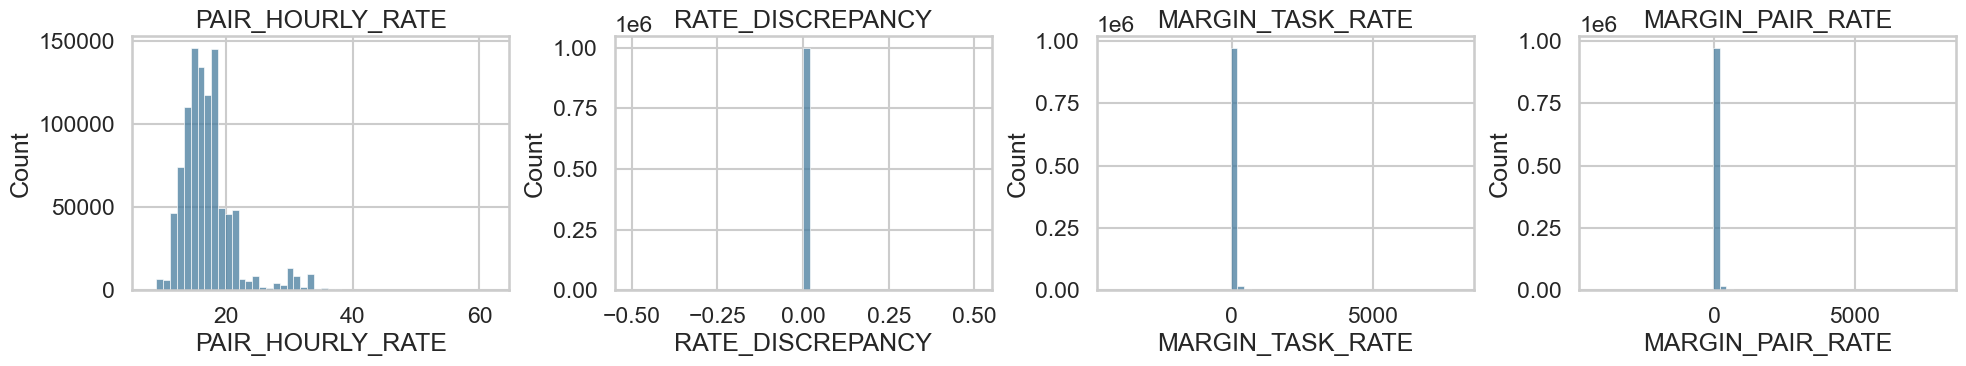

## Availability features

,count,mean,std,min,25%,50%,75%,max
WORKING_DAYS_PER_WEEK,997933.0,6.920092,0.346093,4.0,7.00000,7.000000,7.0,7.0
WEEKEND_WORKER,997933.0,0.979365,0.142158,0.0,1.00000,1.000000,1.0,1.0
NIGHT_SHIFT,997933.0,0.000028,0.005297,0.0,0.00000,0.000000,0.0,1.0
SHIFT_HOURS_PER_DAY,997925.0,10.000000,0.000000,10.0,10.00000,10.000000,10.0,10.0
AVAILABLE_HOURS_IN_WINDOW,997922.0,30.940155,302.345627,-7280.0,5.00000,20.000000,30.0,241080.0
SHIFT_OVERLAP_PCT,992947.0,0.766027,0.260676,-0.0,0.54935,0.845666,1.0,1.0


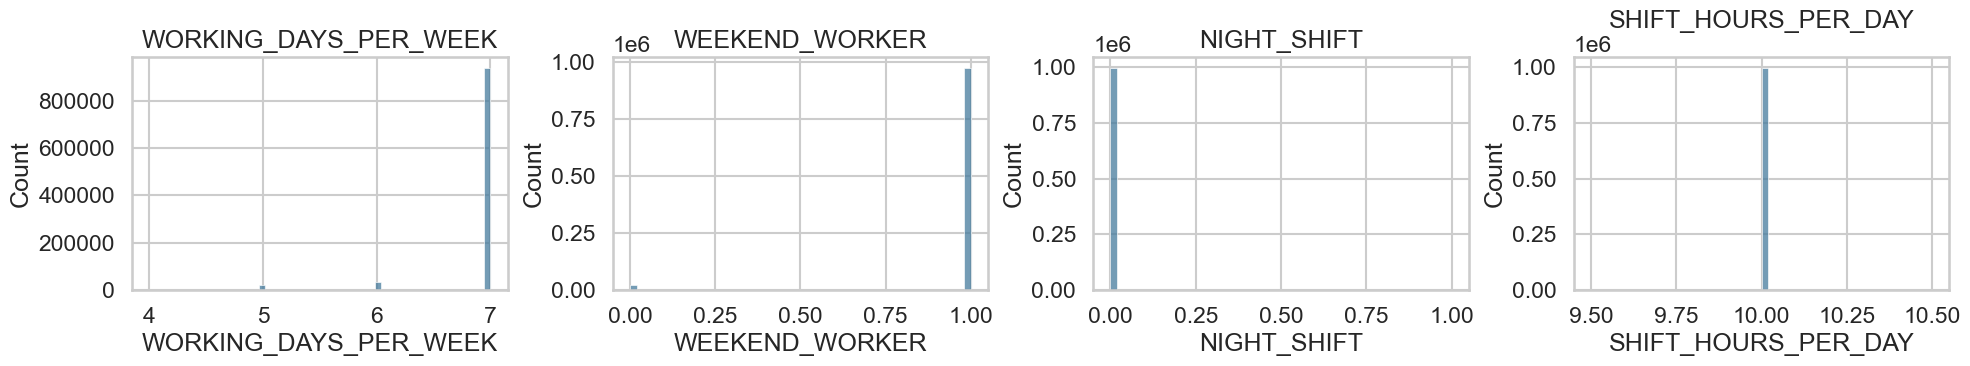

In [3]:
for group_name, columns in FEATURE_GROUPS.items():
    display(Markdown(f"## {group_name.title()} features"))
    available_columns = [column for column in columns if column in enriched.columns]
    if not available_columns:
        continue
    numeric_subset = enriched[available_columns].apply(pd.to_numeric, errors="coerce")
    display(numeric_subset.describe().T)

    plot_columns = available_columns[: min(4, len(available_columns))]
    fig, axes = plt.subplots(1, len(plot_columns), figsize=(5 * len(plot_columns), 4))
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, plot_columns):
        sns.histplot(pd.to_numeric(enriched[column], errors="coerce").dropna(), bins=50, ax=ax, color="#457b9d")
        ax.set_title(column)
        if column.startswith("PRIOR_") or column.endswith("_HOURS") or column.endswith("_COUNT_TRANSLATOR"):
            ax.set_xscale("symlog")
    plt.tight_layout()
    plt.show()

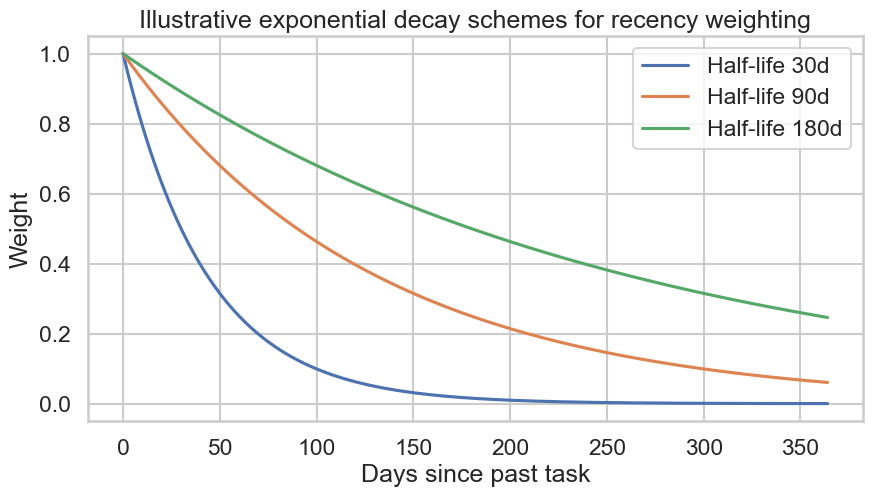

In [4]:
decay_days = np.arange(0, 365)
plt.figure(figsize=(10, 5))
for half_life in [30, 90, 180]:
    weights = np.exp(-np.log(2) * decay_days / half_life)
    plt.plot(decay_days, weights, label=f"Half-life {half_life}d")
plt.title("Illustrative exponential decay schemes for recency weighting")
plt.xlabel("Days since past task")
plt.ylabel("Weight")
plt.legend()
plt.show()

In [5]:
reliability_notes = pd.DataFrame(
    [
        {
            "feature_group": "Experience",
            "reliability_note": "Strong coverage and low missingness because experience can be accumulated from nearly every historical task.",
        },
        {
            "feature_group": "Quality",
            "reliability_note": "Useful but noisier for translators with few scored tasks; rolling quality features should be gated by score count.",
        },
        {
            "feature_group": "Punctuality",
            "reliability_note": "Generally computable, but timestamp anomalies and missing workflow timestamps can distort delay-based features.",
        },
        {
            "feature_group": "Cost",
            "reliability_note": "Reliable when exact client and pair joins exist; unmatched joins create structured missingness.",
        },
        {
            "feature_group": "Availability",
            "reliability_note": "Available for most translators, but overlap features are approximate for night shifts because schedules are recurring weekly templates.",
        },
    ]
)
display(reliability_notes)
display(
    enriched["AVAILABILITY_FEATURE_RELIABILITY"]
    .value_counts(dropna=False)
    .rename_axis("reliability_flag")
    .reset_index(name="rows")
)

,feature_group,reliability_note
0,Experience,Strong coverage and low missingness because ex...
1,Quality,Useful but noisier for translators with few sc...
2,Punctuality,"Generally computable, but timestamp anomalies ..."
3,Cost,Reliable when exact client and pair joins exis...
4,Availability,"Available for most translators, but overlap fe..."


,reliability_flag,rows
0,standard_day_shift,997905
1,approximate_night_shift,28
